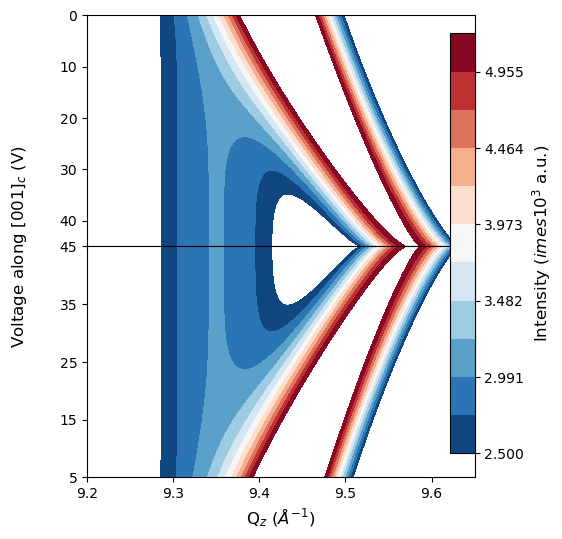

In [1]:
import matplotlib.pyplot as plt
import numpy as np

# --- Data Simulation ---
# Axes
qz = np.linspace(9.2, 9.65, 100)
voltage = np.linspace(5, 45, 100)
Q, V = np.meshgrid(qz, voltage)

# Butterfly Shape Simulation
# Center of the peak shifts with voltage
# Base center at 9.55
# Shifts left as voltage increases (parabolic or switching behavior)
center_shift = 0.08 * np.exp(-((V - 25)/15)**2) 
# Peak 1 (Main)
mu1 = 9.58 - center_shift
# Peak 2 (Shoulder/Splitting)
mu2 = 9.35 + 0.5 * center_shift

# Intensity
Z = np.zeros_like(Q)
# Main peak (High intensity, Red)
Z += 5.0 * np.exp(-((Q - mu1)/0.06)**2)
# Secondary lobe (Lower intensity, Blue/White)
Z += 3.0 * np.exp(-((Q - mu2)/0.15)**2)

# Add noise/texture
Z += np.random.normal(0, 0.1, Z.shape)

# Top Panel (Mirrored/Reversed for visual effect as per image)
# Actually the image shows 0-45 and 5-45. Let's make one continuous plot
# split by a line, but using the same data structure for simplicity.
# The image seems to show hysteresis (Loop).
# Top half: 0 to 45 (or 45 to 0?)
# Bottom half: 45 to 0?
# Let's simulate the "Pinch" effect at ~45V (middle)

voltage_full = np.linspace(0, 90, 200) # 0-45 then 45-0 effectively
Q_f, V_f = np.meshgrid(qz, voltage_full)
# Shift logic for loop
eff_V = np.abs(V_f - 45) # 45 is the pinch point
center_shift_f = 0.15 * (eff_V / 45)**0.5
mu_f = 9.55 - center_shift_f
Z_f = 5.0 * np.exp(-((Q_f - mu_f)/0.05)**2) # Main sharp peak
Z_f += 2.5 * np.exp(-((Q_f - (mu_f - 0.2))/0.1)**2) # Broad tail


# --- Plotting ---
fig, ax = plt.subplots(figsize=(5, 6), dpi=150)

# ContourF
# Diverging Colormap: RdBu_r
levels = np.linspace(2.5, 5.2, 12)
cmap = plt.cm.RdBu_r
# Using Z_f but mapping Y axis to 0-45-0 or similar? 
# The image y-axis is 'Voltage along [001]c (V)'
# Top panel 0-45, Bottom 5-45?
# Let's just plot as one block 0-45 and mirrored
# Actually, let's just create two subplots to match exactly.

plt.close(fig)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(5, 6), sharex=True, gridspec_kw={'hspace': 0})

# Top Panel (0 - 45)
V_top = np.linspace(0, 45, 50)
Q_t, Vt = np.meshgrid(qz, V_top)
# Shape: Wide at 0, Narrow at 45
shift_t = 0.15 * ((45 - Vt)/45)**0.8
Z_top = 5.0 * np.exp(-((Q_t - (9.58 - shift_t))/0.06)**2) + 3.0 * np.exp(-((Q_t - 9.35)/0.15)**2)
cf1 = ax1.contourf(Q_t, Vt, Z_top, levels=levels, cmap=cmap)
ax1.invert_yaxis() # 0 at top
ax1.set_ylabel('Voltage along [001]$_c$ (V)', fontsize=12)
ax1.yaxis.set_label_coords(-0.15, 0) # Center the label across both

# Bottom Panel (45 - 5?)
V_bot = np.linspace(45, 5, 50)
Q_b, Vb = np.meshgrid(qz, V_bot)
# Same shape logic (symmetric)
shift_b = 0.15 * ((45 - Vb)/45)**0.8
Z_bot = 5.0 * np.exp(-((Q_b - (9.58 - shift_b))/0.06)**2) + 3.0 * np.exp(-((Q_b - 9.35)/0.15)**2)
cf2 = ax2.contourf(Q_b, Vb, Z_bot, levels=levels, cmap=cmap)
ax2.set_xlabel(r'Q$_z$ ($\AA^{-1}$)', fontsize=12)

# Colorbar
cbar_ax = fig.add_axes([0.85, 0.15, 0.05, 0.7])
cbar = fig.colorbar(cf2, cax=cbar_ax)
cbar.set_label(r'Intensity ($	imes 10^3$ a.u.)', fontsize=12)

# Ticks
ax1.set_yticks([0, 10, 20, 30, 40, 45])
ax2.set_yticks([35, 25, 15, 5])
ax2.set_xticks([9.2, 9.3, 9.4, 9.5, 9.6])

plt.show()
